# 第 3+4 步「denoiser 训练 + 采样」· CPU 测试版

> 🧪 **这是缩小版,用于本地 CPU 快速跑通验证**(不是论文严格配置)。相对原版的改动:
> - 数据维度 `d_outer`: 64 → **16**,`d_inner`: 16 → **4**(更低维、更易学)
> - U-Net 通道 `dim`: 64 → **16**(模型从 ~14.9M 参数降到 ~1.1M)
> - 数据量 `N₀`: 65536 → **4096**,`epoch`: 20 → **40**(epoch 调高以充分收敛、压低 off-support ratio)
> - 强制用 **CPU**(`CUDA_VISIBLE_DEVICES=""`);用独立的 `hyperparameters_test.npz` 和独立 checkpoint,**不与原版冲突**
> - 图内文字用英文(避免无中文字体时显示方框);验证目标与原版一致,噪声锚点仍是 √3(16/4 与 64/16 的 off/on 比都是 3)

- **第 3 步(训练)**:让网络 `ε_θ(x_t,t)` 学会从带噪样本预测当初加进去的噪声 `ε`。
- **第 4 步(采样)**:把训好的网络反过来用,从纯噪声 `x_T~N(0,I)` 一步步去噪生成新样本。

In [12]:
# ---- 环境准备 (CPU 测试版) ----
%matplotlib inline
import os, sys, time
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

# 测试版强制使用 CPU：置空 = 对进程隐藏所有 GPU，torch.cuda.is_available() 即为 False
os.environ["CUDA_VISIBLE_DEVICES"] = ""

# 自动定位 simulations 目录（含 train.py），无论本 notebook 放在哪层文件夹
_here = os.getcwd()
_cands = [_here, os.path.dirname(_here),
          os.path.join(_here, "simulations"),
          os.path.join(os.path.dirname(_here), "simulations"),
          r"H:\My Drive\Research\DAM\code\GGDMOptim\simulations"]
SIM_DIR = next((c for c in _cands if os.path.exists(os.path.join(c, "train.py"))), _here)
os.chdir(SIM_DIR); sys.path.insert(0, SIM_DIR)

import numpy as np, torch
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from unet_1d import Unet1D
from diffusion import GuidedGaussianDiffusion, extract
from train import LinearLatentData, SingleStepIterator, set_seed

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
set_seed(2345)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# 测试版维度：d_outer=16 / d_inner=4。用独立的 *_test.npz，首次运行会按新维度自动生成。
# 注意：若复用原版 hyperparameters.npz，会从文件里读到旧的 64/16，传进去的维度会被忽略！
g = LinearLatentData("data/linear_latent/hyperparameters_test.npz", d_inner=4, d_outer=16, r_off=9)
M = g.A.T @ g.A
print("d_outer=%d  d_inner=%d  A.shape=%s" % (int(g.d_outer), int(g.d_inner), tuple(g.A.shape)))

# 无条件 denoiser：dim=16 是 U-Net 通道宽度，image_size=16 是数据维度（两者独立）
model = Unet1D(dim=16, conditional=False)
diff  = GuidedGaussianDiffusion(model=model, image_size=16, timesteps=200)
diff.to(device)
n_params = sum(p.numel() for p in diff.model.parameters())
print("Unet1D 参数量: %.2fM | T=%d" % (n_params/1e6, diff.num_timesteps))

device: cpu
d_outer=16  d_inner=4  A.shape=(4, 16)
Unet1D 参数量: 1.13M | T=200


## 第 3 步 · 训练目标

把一个真实样本 `x_0` 随机加噪到某个 `t`，让网络预测加进去的噪声 `ε`：
$$\mathcal L(\theta)=\mathbb E_{x_0,\,t,\,\varepsilon}\big\|\varepsilon_\theta(x_t,t)-\varepsilon\big\|^2,\qquad x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\varepsilon$$
"预测噪声"等价于"学 score"：`s(x_t,t) = -ε_θ/√(1-ᾱ_t)`。

对应代码：`diffusion.py` 的 `forward()`（随机抽 t）→ `p_losses()`（加噪 + MSE，L109）。
训练循环直接用仓库的 `SingleStepIterator`（即 `main.py` 的 `pretrain()` 逻辑）。

## 第 3 步 · 训练（论文配置）

| 参数 | 论文值 | 代码 |
|---|---|---|
| 初始数据集大小 N₀ | 65536 | `--N_0` |
| epoch 数 | 20 | `--pre_num_episodes` |
| batch size | 32 | `--pre_bs` |
| 学习率 | 1e-4 | `--pre_lr` |
| 时间步 T | 200 | `--T` |

**等价命令行**（README）：
```
python main.py --x_type linear_latent --pretrain --pre_lr 1e-4 \
  --pre_num_episodes 20 --pre_bs 32 \
  --pretrain_ckpt_folder checkpoints/pretrained
```
下面的 cell 做同样的事，并把 loss 曲线画出来、存 checkpoint。已有 checkpoint 时直接加载、跳过训练。

In [13]:
# 测试配置（CPU 友好；非论文严格配置）
N0, EPOCHS, BS, LR = 4096, 40, 32, 1e-4
CKPT = "checkpoints/pretrained/linear_latent_test_d16_epoch_40.pth"

if os.path.exists(CKPT):
    info = torch.load(CKPT, map_location=device)
    diff.load_state_dict(info["model_state_dict"])
    print("已加载现成 checkpoint:", CKPT, "| epoch", info.get("epoch"))
    losses = None
else:
    print(f"未发现 checkpoint，开始训练 (N0={N0}, epochs={EPOCHS}, 缩小版)...")
    print("ℹ️ 缩小版模型/数据，CPU 上约十几分钟（epoch=40）。")
    set_seed(2345)
    data = torch.from_numpy(g.generate_x(N0)).float()
    loader = DataLoader(TensorDataset(data), batch_size=BS)
    opt = torch.optim.Adam(diff.model.parameters(), lr=LR, betas=(0.9, 0.99))

    diff.train()
    trainer = SingleStepIterator(diff, opt, log_dir="logs/notebook_pretrain_test")  # 测试专用日志目录
    t0 = time.time()
    trainer.train(loader, num_episodes=EPOCHS)
    print("训练耗时 %.1f 分钟" % ((time.time()-t0)/60))
    losses = trainer.stats["loss_diffusion"]

    # 存 checkpoint（格式同 main.py save_checkpoint）
    os.makedirs(os.path.dirname(CKPT), exist_ok=True)
    torch.save({"x_type": "linear_latent", "epoch": EPOCHS,
                "model_state_dict": diff.state_dict()}, CKPT)
    print("已保存 checkpoint:", CKPT)

未发现 checkpoint，开始训练 (N0=4096, epochs=40, 缩小版)...
ℹ️ 缩小版模型/数据，CPU 上约十几分钟（epoch=40）。


diffusion training epoch 0:   0%|          | 0/128 [00:00<?, ?it/s]

diffusion training epoch 1:   0%|          | 0/128 [00:00<?, ?it/s]

diffusion training epoch 2:   0%|          | 0/128 [00:00<?, ?it/s]

diffusion training epoch 3:   0%|          | 0/128 [00:00<?, ?it/s]

...

diffusion training epoch 36:   0%|          | 0/128 [00:00<?, ?it/s]

diffusion training epoch 37:   0%|          | 0/128 [00:00<?, ?it/s]

diffusion training epoch 38:   0%|          | 0/128 [00:00<?, ?it/s]

diffusion training epoch 39:   0%|          | 0/128 [00:00<?, ?it/s]

训练耗时 12.7 分钟
已保存 checkpoint: checkpoints/pretrained/linear_latent_test_d16_epoch_40.pth


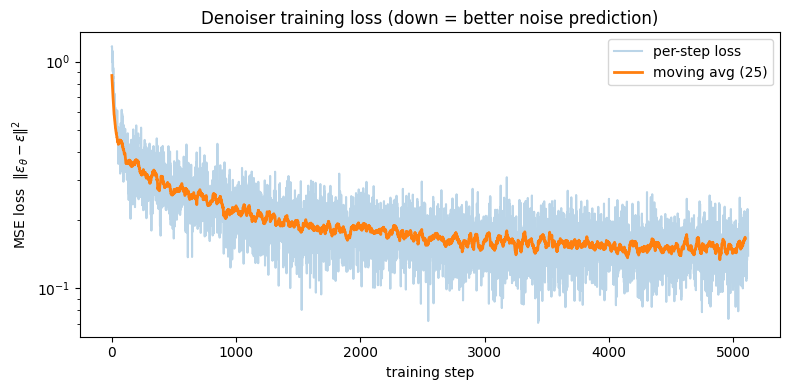

首/末步 loss: 1.1665 → 0.1396


In [15]:
# loss 曲线（仅当本次实际训练了才有）
if losses is not None:
    losses = np.array(losses)
    plt.figure(figsize=(8, 4))
    plt.plot(losses, alpha=0.3, label="per-step loss")
    # 滑动平均看趋势
    k = max(1, len(losses)//200)
    smooth = np.convolve(losses, np.ones(k)/k, mode="valid")
    plt.plot(np.arange(len(smooth)), smooth, lw=2, label=f"moving avg ({k})")
    plt.xlabel("training step"); plt.ylabel(r"MSE loss  $\|\epsilon_\theta - \epsilon\|^2$"); plt.legend()
    plt.title("Denoiser training loss (down = better noise prediction)"); plt.yscale("log")
    plt.tight_layout(); plt.show()
    print("首/末步 loss: %.4f → %.4f" % (losses[0], losses[-1]))
else:
    print("加载了现成 checkpoint，无本次训练 loss 曲线。")

## 第 4 步 · 无条件采样：从噪声生成数据

把训好的 denoiser 反过来用：`x_T~N(0,I)` → 逐步去噪 → `x_0`。
对应 `diffusion.py`：`sample()`(L99) → `p_sample()`(L92) → `p_mean_variance()`(L81)。

**验证目标**：生成样本的 off-support ratio 应 ≈ 0（落在 16 维流形上），和第 1/2 步的锚点对照
（真实数据≈0，纯噪声≈√3）。

sampling:   0%|          | 0/200 [00:00<?, ?it/s]

生成样本 off-ratio mean=0.099  (真实数据≈0.000, 纯噪声≈√3=1.73)
生成样本 ‖x‖ mean=1.76  (真实数据≈√4=2)


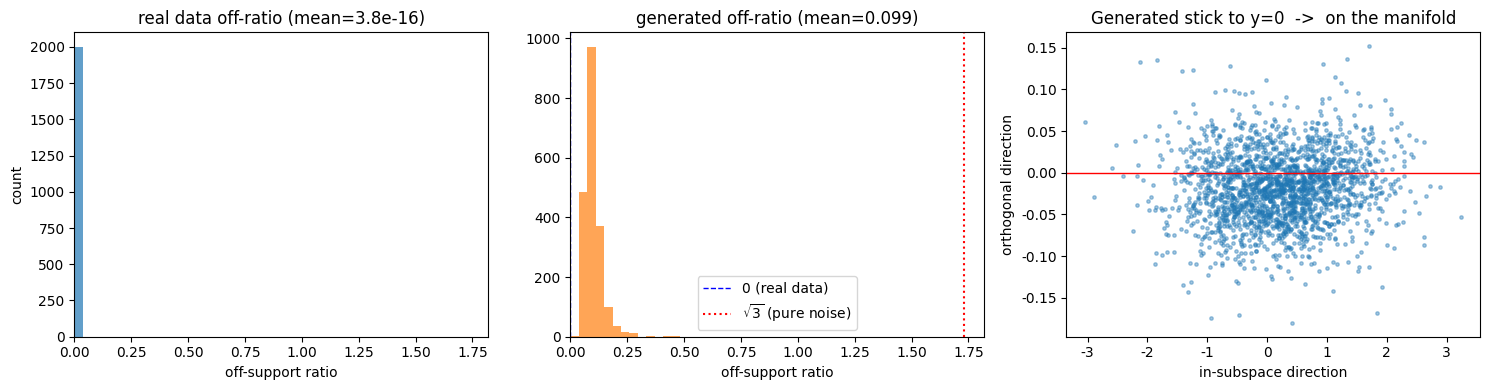

In [18]:
diff.eval()
set_seed(0)
with torch.no_grad():
    samples = diff.sample(num_samples=2000)          # 无条件采样
samples_np = samples.cpu().numpy()

r_samp = g.off_support_ratio(samples_np)
r_data = g.off_support_ratio(g.generate_x(2000))     # 真实数据锚点
print("生成样本 off-ratio mean=%.3f  (真实数据≈%.3f, 纯噪声≈√3=1.73)"
      % (r_samp.mean(), r_data.mean()))
print("生成样本 ‖x‖ mean=%.2f  (真实数据≈√4=2)" % np.linalg.norm(samples_np, axis=1).mean())

# 真实数据 off-ratio ≈ 0（一根针），和 generated 叠一起会看不见 → 拆成两个子图，共享 x 轴范围便于对比
xmax = max(float(r_samp.max()), np.sqrt(3)) * 1.05
bins = np.linspace(0, xmax, 50)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# (1) 真实数据：应是 0 处的一根针
ax[0].hist(r_data, bins=bins, color="tab:blue", alpha=0.7)
ax[0].set_xlim(0, xmax)
ax[0].set_xlabel("off-support ratio"); ax[0].set_ylabel("count")
ax[0].set_title("real data off-ratio (mean=%.1e)" % r_data.mean())

# (2) 生成样本：分布 + 两个锚点参考线（0=真实数据, √3=纯噪声）
ax[1].hist(r_samp, bins=bins, color="tab:orange", alpha=0.7)
ax[1].axvline(0.0, color="b", ls="--", lw=1, label="0 (real data)")
ax[1].axvline(np.sqrt(3), color="r", ls=":", label=r"$\sqrt{3}$ (pure noise)")
ax[1].set_xlim(0, xmax)
ax[1].set_xlabel("off-support ratio"); ax[1].legend()
ax[1].set_title("generated off-ratio (mean=%.3f)" % r_samp.mean())

# (3) 2D 投影：生成样本是否贴在 y=0（流形）上
in_dir = g.A[0] / np.linalg.norm(g.A[0])
rv = np.random.randn(int(g.d_outer)); rv = rv - rv @ M; off_dir = rv / np.linalg.norm(rv)
ax[2].scatter(samples_np @ in_dir, samples_np @ off_dir, s=6, alpha=0.4)
ax[2].axhline(0, color="r", lw=1)
ax[2].set_xlabel("in-subspace direction"); ax[2].set_ylabel("orthogonal direction")
ax[2].set_title("Generated stick to y=0  ->  on the manifold")
plt.tight_layout(); plt.show()

### 反向轨迹：采样是加噪的逆过程

记录一次采样中 `x_t` 的 off-ratio 随 t 从 T→0 的变化：应从 √3（纯噪声）一路降到 0（流形上），
正好和第 2 步的加噪曲线**反着走**。

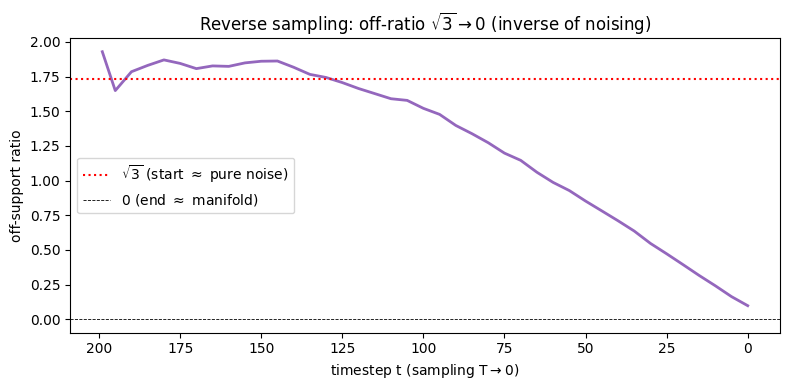

In [19]:
@torch.no_grad()
def sample_with_trace(n=1000):
    img = torch.randn((n, diff.image_size), device=device)
    trace = []
    for t in range(diff.num_timesteps - 1, -1, -1):
        img = diff.p_sample(img, t)
        if t % 5 == 0 or t == diff.num_timesteps - 1:
            trace.append((t, g.off_support_ratio(img.cpu().numpy()).mean()))
    return np.array(trace)

set_seed(1)
tr = sample_with_trace(1000)
plt.figure(figsize=(8, 4))
plt.plot(tr[:, 0], tr[:, 1], lw=2, color="tab:purple")
plt.axhline(np.sqrt(3), color="r", ls=":", label=r"$\sqrt{3}$ (start $\approx$ pure noise)")
plt.axhline(0, color="k", lw=0.6, ls="--", label=r"0 (end $\approx$ manifold)")
plt.gca().invert_xaxis()                              # t 从 T→0
plt.xlabel(r"timestep t (sampling T$\to$0)"); plt.ylabel("off-support ratio")
plt.title(r"Reverse sampling: off-ratio $\sqrt{3}\to 0$ (inverse of noising)"); plt.legend()
plt.tight_layout(); plt.show()

## 验证 denoiser 质量 · Tweedie 恢复

直接测"网络会不会预测噪声"：取真实 `x_0` 加噪到不同 `t` → 网络预测噪声 → 用 Tweedie 还原 `x̂_0`。
- **低 t**：噪声少，`x̂_0` 应非常接近真 `x_0`（相对误差小）
- **高 t**：信息基本被噪声淹没，`x̂_0` 只能塌向数据的"平均猜测"（误差大）

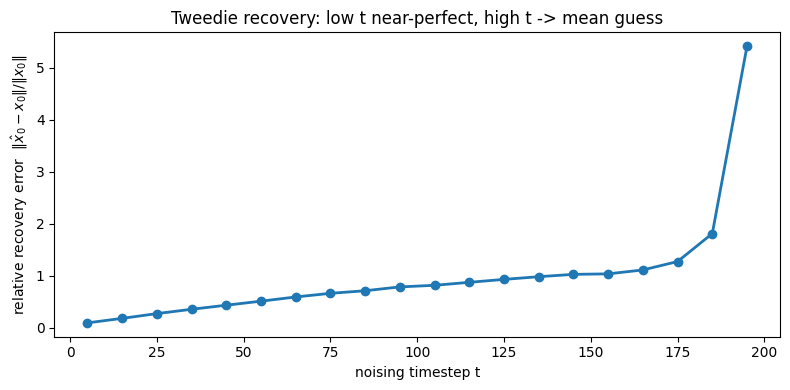

t=5 相对误差=0.095  | t=195 相对误差=5.414


In [20]:
diff.eval()
x0 = torch.from_numpy(g.generate_x(1000)).float().to(device)
ts = list(range(5, 200, 10))
rel_err = []
with torch.no_grad():
    for t in ts:
        tt = torch.full((x0.shape[0],), t, device=device, dtype=torch.long)
        eps = torch.randn_like(x0)
        xt = (extract(diff.sqrt_alphas_cumprod, tt, x0.shape) * x0
              + extract(diff.sqrt_one_minus_alphas_cumprod, tt, x0.shape) * eps)
        pred = diff.model(xt, tt, None)
        x0_hat = (extract(diff.sqrt_recip_alphas_cumprod, tt, xt.shape) * xt
                  - extract(diff.sqrt_recipm1_alphas_cumprod, tt, xt.shape) * pred)
        rel_err.append(((x0_hat - x0).norm(dim=1) / x0.norm(dim=1)).mean().item())

plt.figure(figsize=(8, 4))
plt.plot(ts, rel_err, marker="o", lw=2)
plt.xlabel("noising timestep t"); plt.ylabel(r"relative recovery error  $\|\hat x_0 - x_0\|/\|x_0\|$")
plt.title("Tweedie recovery: low t near-perfect, high t -> mean guess")
plt.tight_layout(); plt.show()
print("t=5 相对误差=%.3f  | t=195 相对误差=%.3f" % (rel_err[0], rel_err[-1]))

## 小结

| 步骤 | 验证 |
|---|---|
| 训练 | loss 下降 → 网络越来越会预测噪声 |
| 采样 | 生成样本 off-ratio ≈ 0、贴在 y=0 → 落在流形上 |
| 反向轨迹 | off-ratio 从 √3 降回 0（加噪逆过程） |
| Tweedie 恢复 | 低 t 误差小、高 t 误差大 → denoiser 学到了数据结构 |

到这里，一个**完整的无条件扩散模型**就齐了：数据生成 → 加噪 → 训 denoiser → 采样。

**下一步（第 5 步，你的核心目标）**：在采样循环里加入梯度引导（G / G_loss / DPS）——
只需把 `p_mean_variance` 换成带引导的版本，就能让生成样本朝高 reward 方向走、同时留在流形上。
本步存下的 checkpoint 会被第 5 步直接复用。